In [16]:
from ching_lung.Exploring_BTSP import plot_jeff2, get_W
import pickle

In [2]:
save_path = "/Users/michaelfinch/CA1-interneuron-GLM/ching_lung/jeffs_data_csv.pkl"
with open(save_path, 'rb') as f:
    jeffs_data_dict = pickle.load(f)

delta_w_list (hz=10): [0.1872531932179919, 0.8013648840834129, 1.174866404793039, 1.609389104289326, 1.5608633306323105, 1.3869656898332592, 0.7935124244175977, 0.09476196639716257]
delta_w_list (hz=20): [0.18042736374927665, 0.7721532057832067, 1.132039697329075, 1.659662702596752, 1.8033177083369243, 1.5326442222337653, 0.7482934938917708, 0.08895321197838811]
delta_w_list (hz=40): [0.17790360245214754, 0.7613525692516147, 1.1162050815836364, 1.636447861964697, 1.9258902491922985, 1.5681692455181153, 0.7449269726620311, 0.08855301756415175]
delta_w_list (hz=100): [0.17666148732592865, 0.7560368391055217, 1.1084117868066468, 1.625022254980923, 1.9975579859681116, 1.5903278255247895, 0.7497258818468034, 0.08912348675788682]
y_mod [0.18725319 0.80136488 1.1748664  1.6093891  1.56086333 1.38696569
 0.79351242 0.09476197]
y_mod [0.18042736 0.77215321 1.1320397  1.6596627  1.80331771 1.53264422
 0.74829349 0.08895321]
y_mod [0.1779036  0.76135257 1.11620508 1.63644786 1.92589025 1.56816925

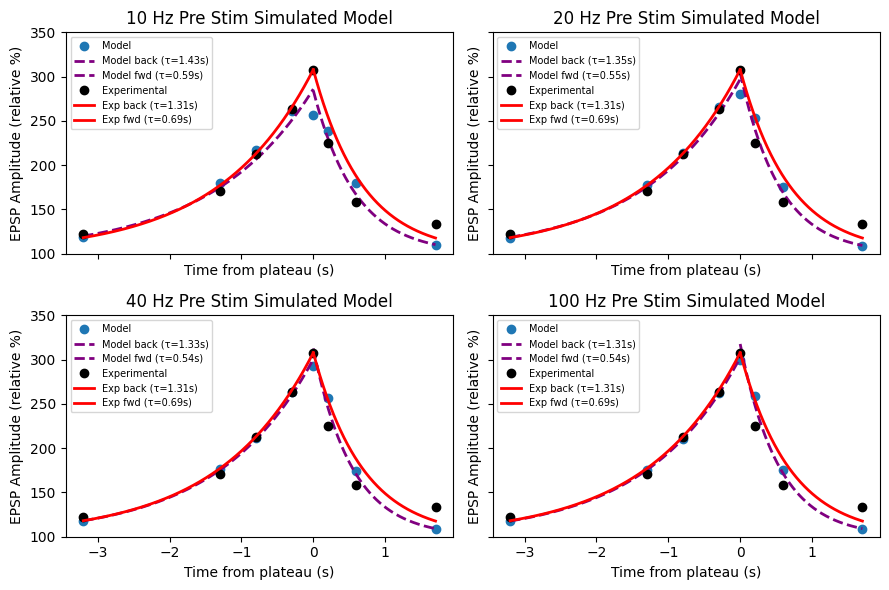

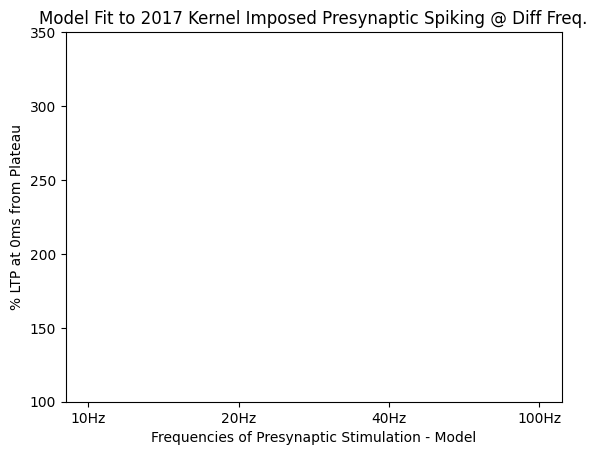

y_mod [0.18725319 0.80136488 1.1748664  1.6093891  1.56086333 1.38696569
 0.79351242 0.09476197]
xx [0.         0.00426065 0.0085213  0.01278195 0.01704261 0.02130326
 0.02556391 0.02982456 0.03408521 0.03834586 0.04260652 0.04686717
 0.05112782 0.05538847 0.05964912 0.06390977 0.06817043 0.07243108
 0.07669173 0.08095238 0.08521303 0.08947368 0.09373434 0.09799499
 0.10225564 0.10651629 0.11077694 0.11503759 0.11929825 0.1235589
 0.12781955 0.1320802  0.13634085 0.1406015  0.14486216 0.14912281
 0.15338346 0.15764411 0.16190476 0.16616541 0.17042607 0.17468672
 0.17894737 0.18320802 0.18746867 0.19172932 0.19598997 0.20025063
 0.20451128 0.20877193 0.21303258 0.21729323 0.22155388 0.22581454
 0.23007519 0.23433584 0.23859649 0.24285714 0.24711779 0.25137845
 0.2556391  0.25989975 0.2641604  0.26842105 0.2726817  0.27694236
 0.28120301 0.28546366 0.28972431 0.29398496 0.29824561 0.30250627
 0.30676692 0.31102757 0.31528822 0.31954887 0.32380952 0.32807018
 0.33233083 0.33659148 0.34085

<Figure size 640x480 with 0 Axes>

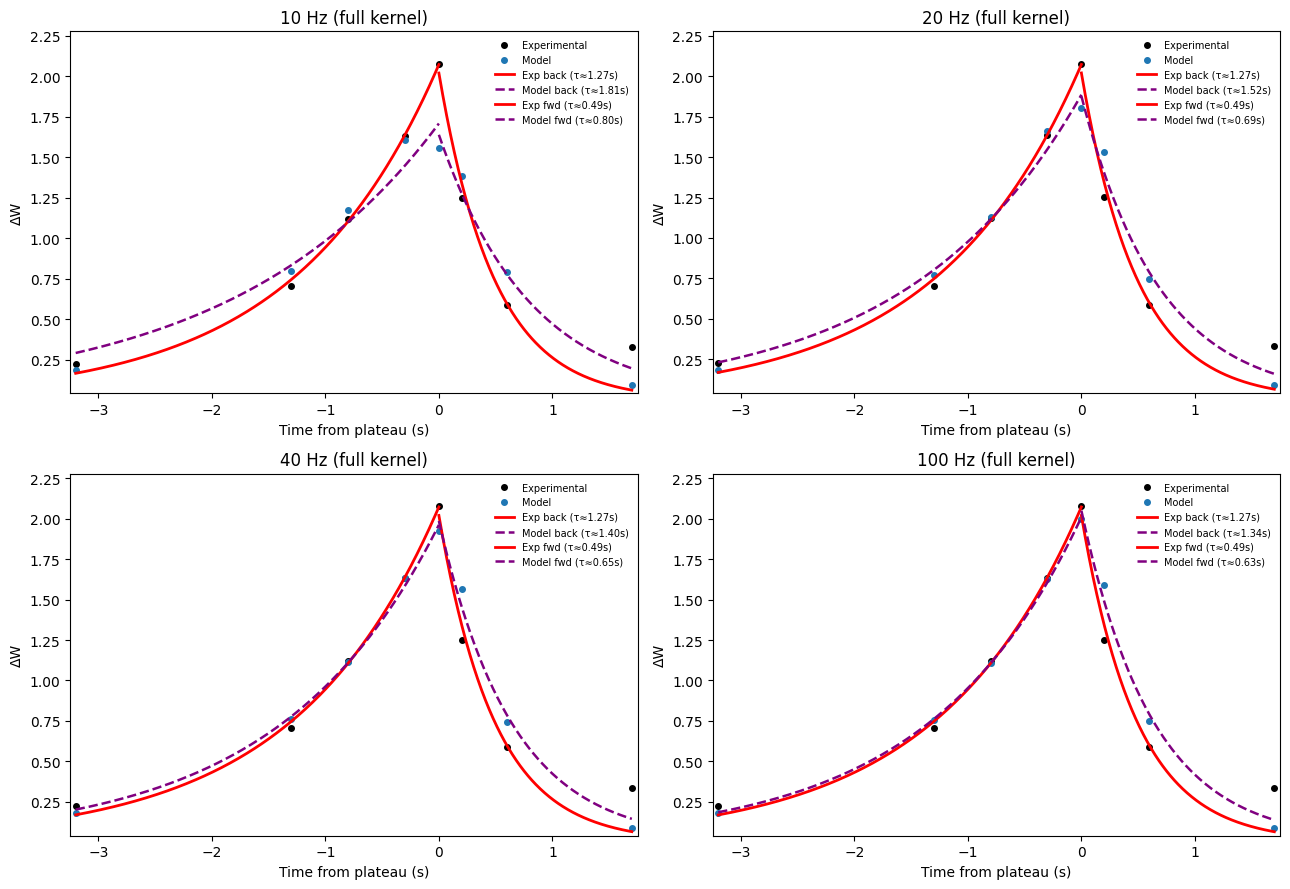

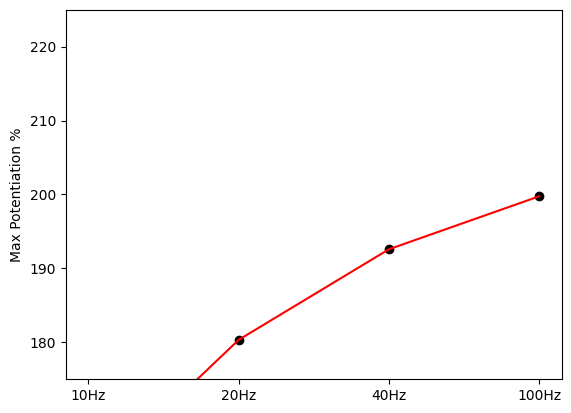

In [3]:

plot_full_intermediates=True
params = {
"tau_et": 1307.3706852728226,
"tau_is": 517.0085321387273,
"lam_et": 119.87951416286887,
"lam_is": 49.984596145977214,
"eta_ms": 0.003982527270809444}


backwards_experiment_per_hz_dict, backwards_model_per_hz_dict = plot_jeff2(params, jeffs_data_dict, plot_full_intermediates)

In [2]:
backwards_model_per_hz_dict[10].keys()

NameError: name 'backwards_model_per_hz_dict' is not defined

model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0
model_dict['x_s'] -0.0


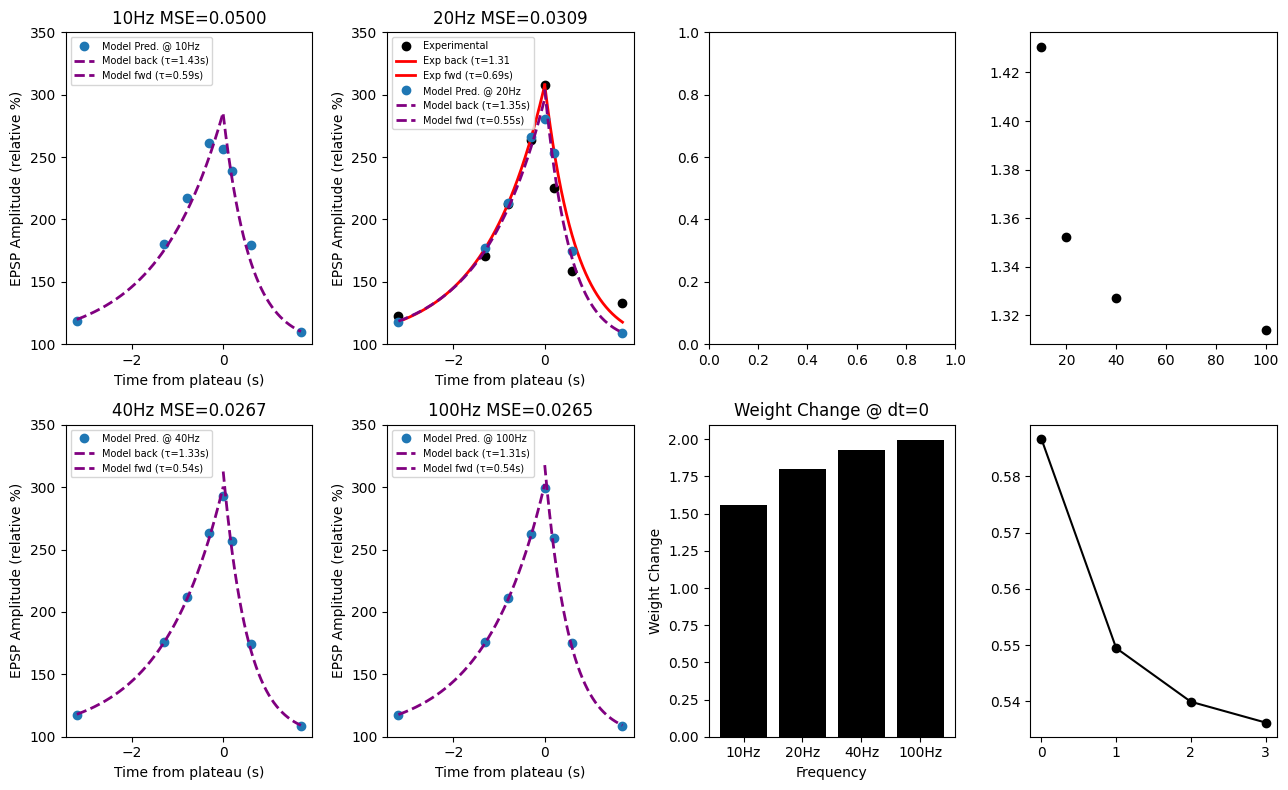

In [34]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs  = plt.subplots(2,4, figsize=(13,8))

axs_list = [axs[0,0], axs[0,1], axs[1,0], axs[1,1]]

model_t0_list = []


apparent_tau_model_list_backwards = []
apparent_tau_model_list_forwards = []

for i, hz in enumerate(backwards_experiment_per_hz_dict):
    back_dict = backwards_experiment_per_hz_dict[hz]

    model_dict = backwards_model_per_hz_dict[hz]


    model_at_t0 = model_dict['y_mod'][4]
    model_t0_list.append(model_at_t0)

    print(f"model_dict['x_s'] {model_dict['x_s'][4]}")

    ax = axs_list[i]

    
    label_exp = "Experimental"
    if hz==20:
        ax.plot(back_dict["x_exp_s_backward"], back_dict["y_exp_s_backward"], 'o', color='k', label=label_exp if hz ==20 else None)
        label_tau = f'Exp back (τ={back_dict["TAU_BACK_PAPER"]:.2f}'
        ax.plot(back_dict["xx_b"], back_dict["yy_b"], '-', lw=2.0, color='red', label=label_tau if hz ==20 else None)
        ax.plot(back_dict["xx_f"], back_dict["yy_f"], '-', lw=2.0, color='red', label=f'Exp fwd (τ={back_dict["TAU_FWD_PAPER"]:.2f}s)')

    ax.plot(model_dict["x_s"], model_dict["y_mod"], 'o', label=f"Model Pred. @ {hz}Hz", color='tab:blue')
    ax.plot(model_dict["xx_b"], model_dict["model_backwards_line"], '--', lw=2.0, color='purple', label=f"Model back (τ={model_dict['taumb']:.2f}s)")
    ax.plot(model_dict["xx_f"], model_dict["model_forwards_line"], '--', lw=2.0, color='purple', label=f"Model fwd (τ={model_dict['taumf']:.2f}s)")

    apparent_tau_model_list_backwards.append(model_dict['taumb'])
    apparent_tau_model_list_forwards.append(model_dict['taumf'])


    ax.set_title(f"{hz}Hz MSE={np.mean(np.square(back_dict['y_exp_s_backward']-model_dict['y_mod'])):.4f}")
    ax.set_xlabel("Time from plateau (s)")
    ax.set_ylabel("EPSP Amplitude (relative %)") #("ΔW")
    ax.set_ylim(0, 2.50)
    custom_tick_locations = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
    custom_labels = ['100', '150', '200', '250', '300', '350']
    ax.set_yticks(custom_tick_locations)
    ax.set_yticklabels(custom_labels)
    ax.legend(fontsize=7, loc="upper left")



axs[1,2].bar(range(len(model_t0_list)),model_t0_list, color='k')
axs[1,2].set_xticks(range(4), ["10Hz", "20Hz", "40Hz", "100Hz"])
axs[1,2].set_ylabel("Weight Change")
axs[1,2].set_title("Weight Change @ dt=0")
axs[1,2].set_xlabel("Frequency")



long_range = np.arange(101)
hzs=[10, 20, 40, 100]
for i, hz in enumerate(hzs):
    axs[0,3].plot(long_range[hz], apparent_tau_model_list_backwards[i], marker='o', color='k')



axs[1,3].plot(apparent_tau_model_list_forwards, marker='o', color='k')


plt.tight_layout()
plt.show()




In [ ]:
for hz in backwards_model_per_hz_dict:
    x_arr_int = backwards_model_per_hz_dict[hz][]

array([0.17666149, 0.75603684, 1.10841179, 1.62502225, 1.99755799,
       1.59032783, 0.74972588, 0.08912349])

In [23]:
jeffs_data_dict[hz]['x']

array([ 3200,  1300,   800,   300,     0,  -200,  -600, -1700])

In [27]:
print(params["tau_et"])

1307.3706852728226


k 10
k 20
k 40
k 100


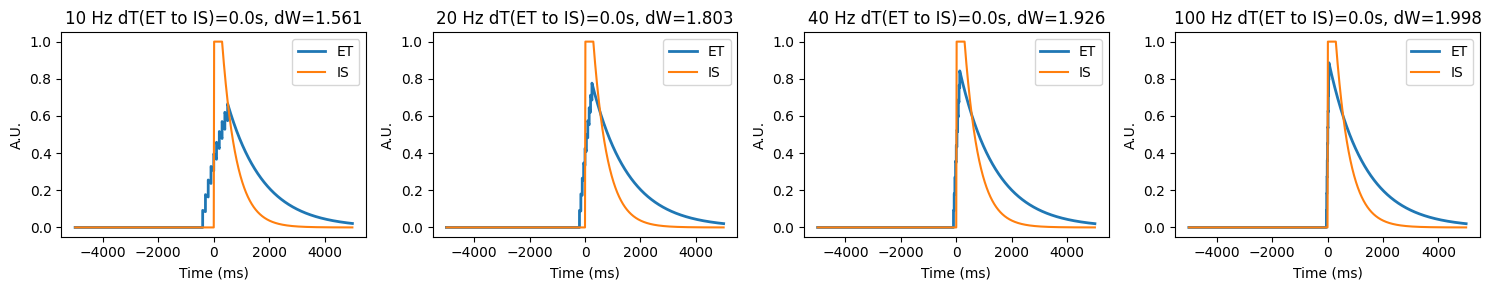

In [28]:

hz_used=20
hz=20
plot=True
special_case=False

x_arr_int = jeffs_data_dict[hz]['x']

et_time_1000_dict = {}

hz_list = [10, 20, 40, 100]

for hz_used in hz_list:

    delta_w_list, et_time_1000, IS = get_W(x_arr_int, post_ms=10000, pre_ms=10000, hz_used=hz_used, plateau_length=300,tau_et =params["tau_et"],tau_is = params["tau_is"],lam_et=params["lam_et"],lam_is=params["lam_is"],dt_ms=1.0, eta_ms = params["eta_ms"], plot_intermediates=False, special_case=True)

    et_time_1000_dict[hz_used] = et_time_1000

# order = [10, 20, 40, 100, "20Hz_full_kernel"]

fig, axs = plt.subplots(1, 4, figsize=(15,3))

# pick keys that actually exist, in the desired order, cap at 5
# keys = [k for k in order if k in et_time_1000_dict][:5]
keys = hz_list

pre_ms = 10000
post_ms = 10000

T_ms = int(pre_ms + post_ms)
t_ms = np.arange(-pre_ms, post_ms, dtype=int)

dw_per_hz_special_0 = []

for i, k in enumerate(keys):
    print(f"k {k}")
    if k!="20Hz_full_kernel":
        y = np.asarray(et_time_1000_dict[k], float)   # y-only series is fine
        W = np.trapz(y*IS, dx=1.0)
        dW = params["eta_ms"] * W
        dW_scaled = (dW+1) *100
        dw_per_hz_special_0.append(dW_scaled)
        # ax = axs[i]
        axs[i].plot(t_ms[5000:15000], y[5000:15000], lw=2, label="ET")
        axs[i].plot(t_ms[5000:15000], IS[5000:15000], label="IS")
        axs[i].set_title(f"{k} Hz dT(ET to IS)=0.0s, dW={dW:.3f}")
        axs[i].set_xlabel("Time (ms)")
        axs[i].set_ylabel("A.U.")
        axs[i].legend()

# # hide the 6th (unused) panel to match the 5-panel layout
# axs[5].axis('off')

plt.tight_layout()
plt.show()

{20: {'x': array([ 3200,  1300,   800,   300,     0,  -200,  -600, -1700]),
  'y': array([0.22379526, 0.70373753, 1.12235791, 1.63483495, 2.07879113,
         1.25141626, 0.58630559, 0.3314659 ])}}